-----
# Vectorising Data with TF-IDF
------

## Notebook Summary

This notebook focuses on tokenising the dataset and performing topic modelling using Latent Dirichlet Allocation (LDA) to uncover the context of emails in the dataset. For efficiency, I have used only 15,000 rows.

The notebook is divided into the following stages:

1. **Data Loading:** Load the cleaned data from the data folder.

2. **Preparing Text:** Preprocess the text for tokenisation, handling stopwords, and using SpaCy to remove irrelevant words.

3. **Vectorising Text:** Apply TF-IDF with a custom tokeniser to convert text into numerical form.

4. **Topic Modelling with LDA:** Group the data into topics and analyse groupings.


## Set Up
----

In [358]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import re
import string
import spacy
import matplotlib.pyplot as plt

## Data Loading
----

In [359]:
emails_df = pd.read_csv('../../data/cleaned_emails.csv', index_col= 0)

In [360]:
# working with subset of data first to assess results
email_subset_df = emails_df[:15000].copy()

## Preparing Text
---

In [361]:
# Combining subject and body to better understand context of emails
email_subset_df['all_text'] = email_subset_df['cleaned_subject'] + ' ' + email_subset_df['cleaned_body']

### Define StopWords

In [362]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/simybasra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [363]:
eng_stop_words = stopwords.words('english')

In [364]:
# since punc was removed in cleaning, I need to do the same for stop words
# using regexp to remove all characters which are not words or whitespaces (punctuation)
processed_stop_words = [re.sub(r'[^\w\s]', '', word) for word in eng_stop_words]

In [365]:
# custom list of stop words, all are in lower case since in tokenizer I will force case to be lower
greetings = [
    'hello', 'hi', 'dear', 'regards', 'thanks', 'thank', 'sincerely', 'best', 'regard', 'regarding', 'activity',
    'cordially'
]

email_jargon = [
    're', 'fw', 'cc', 'forwarded', 'forward', 'original message', 'original', 'bcc', 'x', 'subject', 'message', 
    'email', 'mail', 'intend', 'recipient', 'sender', 'senders'
]

std_phrases = [
    'also', 'please', 'let', 'know', 'kindly', 'attached', 'find', 'below', 'attach', 'pm', 'am', 'like', 'see', 
    'time', 'us', 'right', 'said', 'information', 'team', 'office', 'company', 'order', 'change', 'provide', 'give', 
    'scheduled', 'made', 'play', 'next', 'step', 'steps', 'act', 'upon', 'hereto', 'copy']

std_words = [
    'go', 'get', 'take', 'come', 'think', 'make', 'enron', 'going', 'look', 'may', 'image', 'list', 'would', 'could', 
    'fax', 'name', 'one', 'want', 'call', 'use', 'new', 'need', 'meet', 'work', 'receives', 'receiving', 'back', 
    'great', 'received', 'first', 'last', 'much', 'since', 'many', 'notify'
]

irrelevant_words = [
    'phone', 'long', 'term', 'good', 'web', 'site', 'feel', 'free', 'question', 'questions', 'contact', 'concern', 
    'put', 'per', 'dec', 'together', 'im', 'sure', 'night', 'soon', 'possible', 'third', 'parties', 'hope', 'well', 
    'even', 'though', 'request', 'still', 'following', 'active', 'help', 'available', 'game', 'way', 'position', 
    'two', 'updated', 'number', 'people', 'group', 'system', 'process', 'start', 'send', 'receive', 'day', 'date'
]

additional_stop_words = [
    'meeting', 'gas', 'business', 'market', 'report', 'power', 'expected', 'comment', 'comments', 'agent', 
    'communication', 'review', 'management', 'plan', 'service', 'issues', 'data', 'numbered', 'pt', 'today', 'based', 
    'id', 'need', 'user', 'deal', 'offer', 'visit', 'houston', 'address', 'online', 'access', 'able', 'sent', 'working', 
    'yards', 'note', 'set', 'changes', 'due', 'support', 'keep', 'credit', 'london', 'discuss', 'current', 'intended', 
    'tofrom', 'place', 'however', 'services', 'reports', 'must', 'check', 'points', 'employees', 'companies', 'operation', 
    'pointed', 'point', 'points', 'pointing', 'cost', 'project', 'value', 'hour', 'area', 'might', 'morning', 'result', 
    'line', 'big', 'guy', 'guys', 'currently', 'opportunity', 'end', 'news', 'city', 'option', 'share', 'including', 
    'part', 'parts', 'approval', 'used', 'looking', 'point', 'file', 'prices', 'say', 'update', 'copy', 'detail', 
    'rate', 'thing', 'fantasy', 'done', 'problem', 'transaction', 'special', 'complete', 'completed', 'completing', 
    'account', 'click', 'link', 'schedule', 'comment', 'member', 'future', 'th', 'thought', 'additional', 'around', 
    'another', 'detail', 'anyone', 'anything', 'else', 'make', 'makes', 'sense', 'rights', 'reserved', 'right', 'unable', 
    'attend', 'attends', 'attending', 'attended', 'website', 'names', 'name', 'named', 'basis', 'relevant'
]

additional_stop_words.extend([
    'just', 'return', 'returns', 'returned', 'returning', 'really', 'actually', 'kind', 'often', 'simply', 'totally', 
    'definitely', 'got', 'numbers', 'numbering', 'already', 'investment', 'project', 'financial', 'market', 'partner', 
    'value', 'costs', 'consult', 'person', 'player', 'clients', 'growth', 'useful', 'important', 'available', 'ensure', 
    'confirm', 'consider', 'got', 'item', 'times', 'high', 'highs', 'low', 'lows', 'long-term', 'year', 'week', 'month', 
    'day', 'confirm', 'understand', 'appreciate', 'response', 'reply', 'feedback', 'software', 'platform', 'code', 'error', 
    'system', 'debug', 'version', 'host', 'data center', 'thank', 'please', 'attached', 'forwarded', 'message', 'kindly', 
    'subject', 'forward', 'the', 'a', 'an', 'of', 'in', 'to', 'on', 'at', 'from', 'for', 'with', 'by', 'about', 'no', 
    'not', 'never', 'none', 'nothing', 'without', 'option', 'better', 'state', 'company', 'customer', 'operation', 'details', 
    'agreement', 'contract', 'deal', 'million', 'continue', 'view', 'texas', 'within', 'unit', 'level', 'believe', 'deals', 
    'issue', 'issues', 'include', 'home', 'program', 'total', 'comment', 'volume', 'north','america', 'conference', 'room', 'rooms',
    'allenhouect', 'estoppel', 'otherwise', 'accept', 'accepting', 'acceptance', 'create', 'andor'
])

new_stop_words = [
    'vice', 'president', 'managing',  'director', 'privacy', 'policy', 'strictly', 'prohibited', 
    'contain', 'confidential', 'requested', 'resource', 'resource', 'type', 'trading', 'operation', 'brent', 'hourly', 'index', 'trading', 'track', 'pleased', 'announce', 
    'published' ,'viewing', 'org', 'chart', 'pass' ,'along', 'delete', 'pending', 'copy', 'attachments', 'attachments'
]

processed_stop_words.extend(new_stop_words)

custom_stop_words = greetings + email_jargon + std_phrases + std_words + irrelevant_words + additional_stop_words

# adding all custom stop words to existing list 
processed_stop_words.extend(custom_stop_words)
processed_stop_words = set(processed_stop_words)

----
**Comment:**

Stop word removal to occur in tokeniser for TF-IDF (below)

### Removing Employee Names, Dates and Organisations

In [366]:
# load the pre-trained spaCy model for NER
nlp = spacy.load('en_core_web_sm')

def remove_names(text):
    # ensuring all text is of type string
    text = str(text)
    # using model to process email text (subject + body)
    doc = nlp(text)
    # need to reverse order in which entities are removed to avoid disrupting order of text
    #  important as otherwise model will not recognise other entities to be removed
    for e in reversed(doc.ents):
        # to remove words where entity is PERSON, ORG or DATE
        if e.label_ in ['PERSON', 'ORG', 'DATE', 'GPE']: 
            # remove the entity by slicing the text: 
            #   keep the part before the entity, skip the entity itself and keep the part after it
            text = text[:e.start_char] + text[e.start_char + len(e.text):]

    return text


In [367]:
email_subset_df['all_text'] = email_subset_df['all_text'].apply(remove_names)

### Prepare Tokeniser

In [368]:
# instantiate stemmer to be used in tokeniser
stemmer = nltk.stem.PorterStemmer()

In [369]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/simybasra/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [370]:
# building a bespoke tokeniser
def my_tokenizer(email):
    
    email = email.lower()
    
    # to remove numbers
    email = re.sub(r'\d+','',email)

    # splitting each sentence by space into words
    listofwords = email.split(' ')
    listoflemm_words = []
    
    for word in listofwords:  
        # filtering out stopwords and any tokens that are just empty strings
        if (word not in processed_stop_words) and (word != ''):
            # stem words to cut words to the base 
            lemm_word = lemmatizer.lemmatize(word)
            listoflemm_words.append(lemm_word)

    return listoflemm_words

## Vectorising Text
----

In [371]:
# instantiate tf-idf vecotriser
my_vectoriser = TfidfVectorizer(max_features=800,
                               min_df = 5,
                               tokenizer= my_tokenizer, # setting tokenizer to my bespoke tokenizer
                               ngram_range=(2,2), # bigrams only
                               token_pattern = None # to remv warning
                               )

In [372]:
# instantiate tf-idf vecotriser
my_vectoriser = TfidfVectorizer(max_features=800,
                               min_df = 5,
                               tokenizer= my_tokenizer, # setting tokenizer to my bespoke tokenizer
                               ngram_range=(2,2), # bigrams only
                               token_pattern = None # to remv warning
                               )
# tokenise text
text_tranform = my_vectoriser.fit_transform(email_subset_df['all_text'])
# create df of results where tokens are columns
email_token_df = pd.DataFrame(columns= my_vectoriser.get_feature_names_out(), data= text_tranform.toarray(), index=email_subset_df.index)

In [373]:
# create df of results where tokens are columns
email_token_df = pd.DataFrame(columns= my_vectoriser.get_feature_names_out(), data= text_tranform.toarray(), index=email_subset_df.index)

## Insights
------

- most important terms, word clouds, words highest score and document similarity.


In [374]:
# summing counts of tokens down the columns
token_count = text_tranform.toarray().sum(axis=0)

In [375]:
# dataframe of top 20 most frequently occurring words in the dataset (15_000 rows)
token_freq = pd.DataFrame(
    {'count': token_count},
    index=my_vectoriser.get_feature_names_out()
).sort_values('count', ascending=False)

In [376]:
token_freq.head(20)

,count
privileged material,61.453205
operational risk,57.610494
binding enforceable,54.129450
evidence binding,54.129450
material sole,54.129450
distribution disclosure,54.129450
property affiliate,54.129450
affiliate party,53.915855
enforceable affiliate,53.915855
others authorized,53.658735


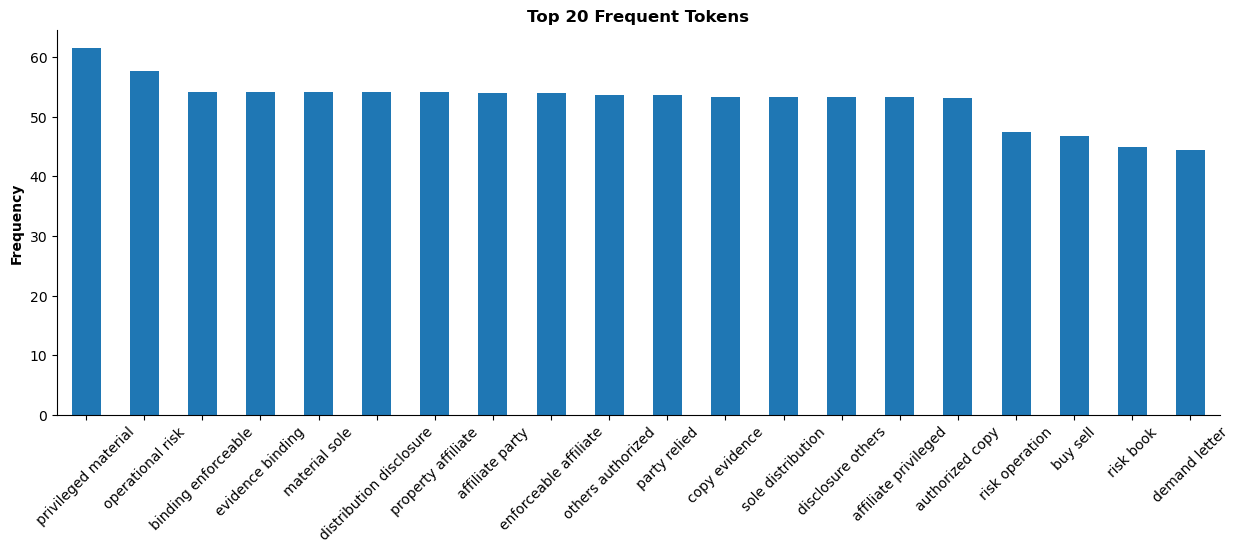

In [381]:
# plot top 20 frequent tokens in dataset (15_000 rows)
token_freq.head(20).plot(kind='bar', figsize=(15, 5), legend=False)
plt.title('Top 20 Frequent Tokens', fontweight = 'bold')
plt.ylabel('Frequency', fontweight = 'bold')
plt.xticks(rotation=45)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

----
**Comment:**

Above bigrams highlight the key themes in the Enron dataset, there is a clear foucs on risk and legal terms. 

**Key Insights:**

1. Legal Terms
-	Terms such as `privileged material`, `binding enforceable`, `distribution disclosure`, `evidence binding`,`affiliate privileged`
-	Suggests many emails seem to focus on confidentiality and legal compliance/agreements.

2. Risk and Financial Terms
-	Terms like `operational risk`,`risk operation`, `risk book`, `buy sell`.
-	Suggests many emails discuss risk management and financial transactions.

After reading more on Enron and its downfall, these findings seem to align. The company faced issues in risky trading, compliance issues and even dodgy affiliations to hide losses. 

Although I spent some time refining the results, I decided not to dwell too long on this step since the focus is on high-level insights at this stage.

The noise also suggests that more complex vectorisation methods may be necessary for better capturing the context. As a next step, I plan to explore word embeddings.


## Topic Modelling with LDA
----

In [382]:
from sklearn.decomposition import LatentDirichletAllocation

# fit the LDA topic model
lda = LatentDirichletAllocation(
    n_components=3, # number of topics
    max_iter=30, # number of iterations of fitting the model
    random_state=1,
    verbose=1
)

# fit lda model to the tokenised text
lda.fit(text_tranform)

iteration: 1 of max_iter: 30
iteration: 2 of max_iter: 30
iteration: 3 of max_iter: 30
iteration: 4 of max_iter: 30
iteration: 5 of max_iter: 30
iteration: 6 of max_iter: 30
iteration: 7 of max_iter: 30
iteration: 8 of max_iter: 30
iteration: 9 of max_iter: 30
iteration: 10 of max_iter: 30
iteration: 11 of max_iter: 30
iteration: 12 of max_iter: 30
iteration: 13 of max_iter: 30
iteration: 14 of max_iter: 30
iteration: 15 of max_iter: 30
iteration: 16 of max_iter: 30
iteration: 17 of max_iter: 30
iteration: 18 of max_iter: 30
iteration: 19 of max_iter: 30
iteration: 20 of max_iter: 30
iteration: 21 of max_iter: 30
iteration: 22 of max_iter: 30
iteration: 23 of max_iter: 30
iteration: 24 of max_iter: 30
iteration: 25 of max_iter: 30
iteration: 26 of max_iter: 30
iteration: 27 of max_iter: 30
iteration: 28 of max_iter: 30
iteration: 29 of max_iter: 30
iteration: 30 of max_iter: 30


LatentDirichletAllocation(max_iter=30, n_components=3, random_state=1,
                          verbose=1)

In [383]:
tokens = my_vectoriser.get_feature_names_out()

# looping thorugh all topics lda has found
for i, topic in enumerate(lda.components_):
    # get top 10 tokens for each topic, these tokens are those most represntative of the topic
    topic_words = ' '.join([tokens[j] for j in topic.argsort()[: -11: -1]])
    print(f'Topic #{i} words: {topic_words}')

Topic #0 words: risk book demand letter global market cash flow associate analyst west desk read directory real estate super bowl natural analysis
Topic #1 words: operational risk risk operation mark calendar greatly appreciated yahoo yahoo shipping handling short notice security approver advise interest listed security
Topic #2 words: privileged material property affiliate evidence binding binding enforceable material sole distribution disclosure affiliate party enforceable affiliate others authorized party relied


----
**Comment:**

**Topic #0: Finance**

*Terms: risk book demand letter global market cash flow associate analyst west desk read directory real estate super bowl natural analysis*

See terms like risk, book , cash flow all of which refer to finance and some sort of trading. We also see terms like real estate and analysis appear for the first topic, perhaps this could be some sort of investments. Term super bowl is interesting, this could be some noise or indicate some sort of financial impact perhaps some advertising or a partnership.

**Topic #1: Operations**

Terms: operational risk risk operation mark calendar greatly appreciated yahoo yahoo shipping handling short notice security approver advise interest listed security
The second topic seems to focus on operations, terms like 'shipping,' 'handling,' and 'short notice' suggest supply chain problems. The frequent occurrence of 'risk' suggests potential issues in regard to operations or security.

**Topic #2: Legal**

*Terms: privileged material property affiliate evidence binding binding enforceable material sole distribution disclosure affiliate party enforceable affiliate 
others authorized party relied*

The third topic points to legal and compliance concerns, with terms like 'binding' and 'affiliate' suggest it involves contracts. 'Disclosure' suggests confidentiality, possibly related to compliance.

Overall, the topic modelling performed better than I expected. There is still some room for improvement and further refinement to make the results better. However, I think its best to move to word embeddings and perform LDA on embeddings to compare the results.

## Summary
---

There are some limitations to TF-IDF with this dataset, I think this is due to the high level of noise in email data. The topics found fit within general business day-to-day operations such as but think further refinement is needed before I move to clustering. The next step is to repeat this process using word embeddings to vectorise the email data to see if this produces better results and deeper understanding of context of emails.

From the results so far, the scope of the project may also change... instead of looking at how to classify work emails this project may also tell us more about what happened with Enron and it's downfall. To be sure, further analysis is required with more complex tools. 